In [2]:
#----- Imports -------------------------------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#----- Semilla global -------------------------------------------------------------------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

#----- Estilo de gráficas -------------------------------------------------------------------------------------------
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

In [3]:
# Carga desde scikit-learn (Esto no requiere una descarga maual)
raw = fetch_california_housing(as_frame=True)
df = raw.frame          # DataFrame completo: features + target
X = raw.data            # Solo features (8 columnas)
y = raw.target          # Solo target: median_house_value (en decenas de miles)

df["MedHouseVal"] = df["MedHouseVal"] * 100_000 # Como raw.target no viene en dólares directos, los múltiplicamos por 100.000
y = y * 100_000

print(f"Forma del dataset: {df.shape}")
print(f"Columnas: {list(df.columns)}")
df.head()

Forma del dataset: (20640, 9)
Columnas: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,452600.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,358500.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,352100.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,341300.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,342200.0


In [4]:
# Revisión de calidad
df.info()
df.isnull().sum()
df.describe().T   # La .T transpone para leer mejor

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,206855.816909,115395.615874,14999.000000,119600.000000,179700.000000,264725.000000,500001.000000


## Definición del problema

**Pregunta:** ¿Es posible estimar el valor mediano de vivienda de un distrito
censal de California a partir de características socioeconómicas y geográficas,
con un MAE menor al 20% del valor mediano observado?

**Variable objetivo:** `MedHouseVal` — valor mediano de vivienda en USD (continua)

**Tipo de tarea:** Regresión supervisada

**Métrica principal:** MAE — elegida por robustez a outliers dado el truncamiento
en $500,000. Se reportan también RMSE y R².

**Limitación conocida:** Los valores mayores a $500,001 están truncados,
lo que introduce sesgo en el extremo superior.

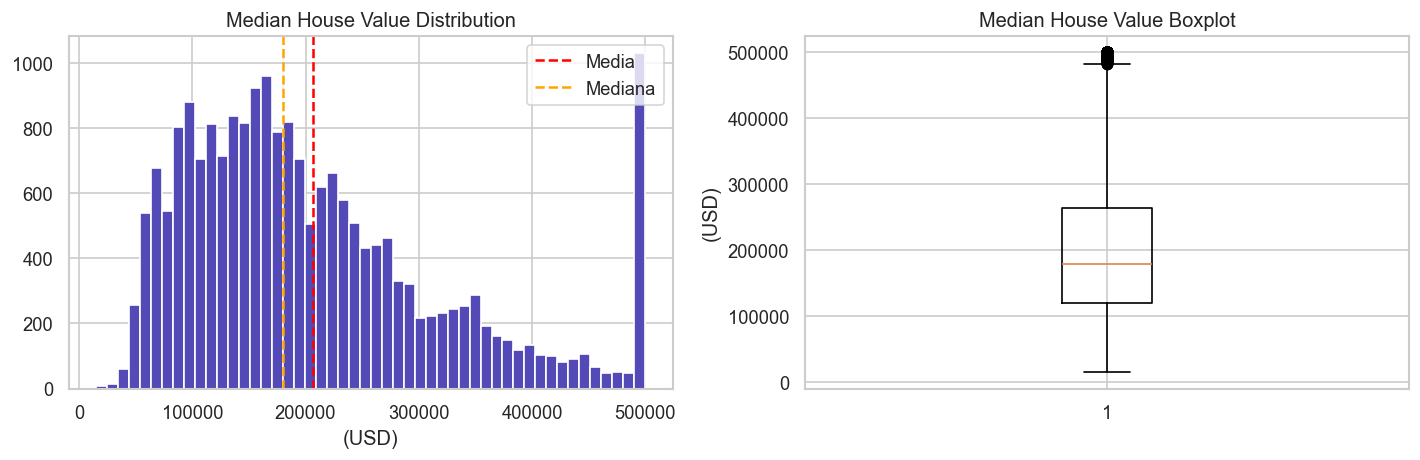

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
axes[0].hist(df["MedHouseVal"], bins=50, color="#534AB7", edgecolor="white")
axes[0].axvline(df["MedHouseVal"].mean(),   color="red",    linestyle="--", label="Media")
axes[0].axvline(df["MedHouseVal"].median(), color="orange", linestyle="--", label="Mediana")
axes[0].set_title("Median House Value Distribution")
axes[0].set_xlabel("(USD)")
axes[0].legend()

# Boxplot
axes[1].boxplot(df["MedHouseVal"], vert=True)
axes[1].set_title("Median House Value Boxplot")
axes[1].set_ylabel("(USD)")

plt.tight_layout()
plt.savefig("figures/fig1_target_dist.png", bbox_inches="tight")
plt.show()

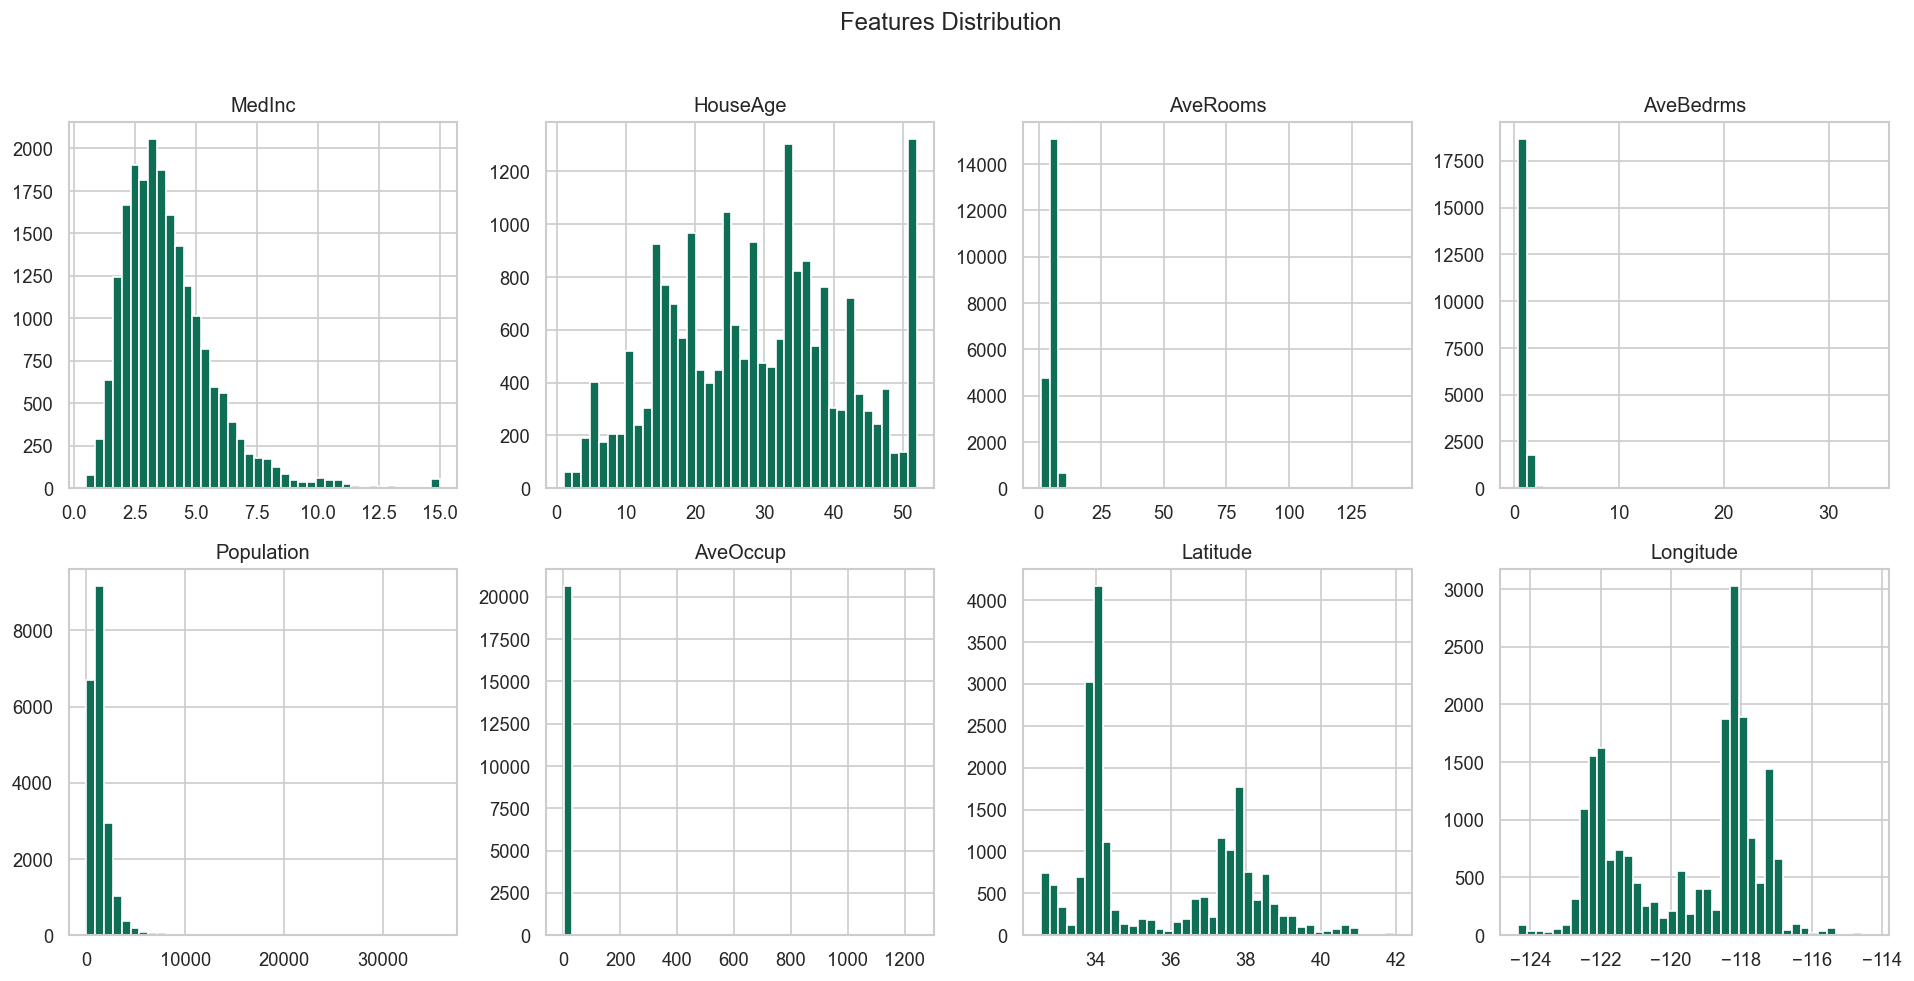

In [6]:
features = X.columns.tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=40, color="#0F6E56", edgecolor="white")
    axes[i].set_title(col)
    axes[i].set_xlabel("")

plt.suptitle("Features Distribution", y=1.02)
plt.tight_layout()
plt.savefig("figures/fig2_features_dist.png", bbox_inches="tight")
plt.show()

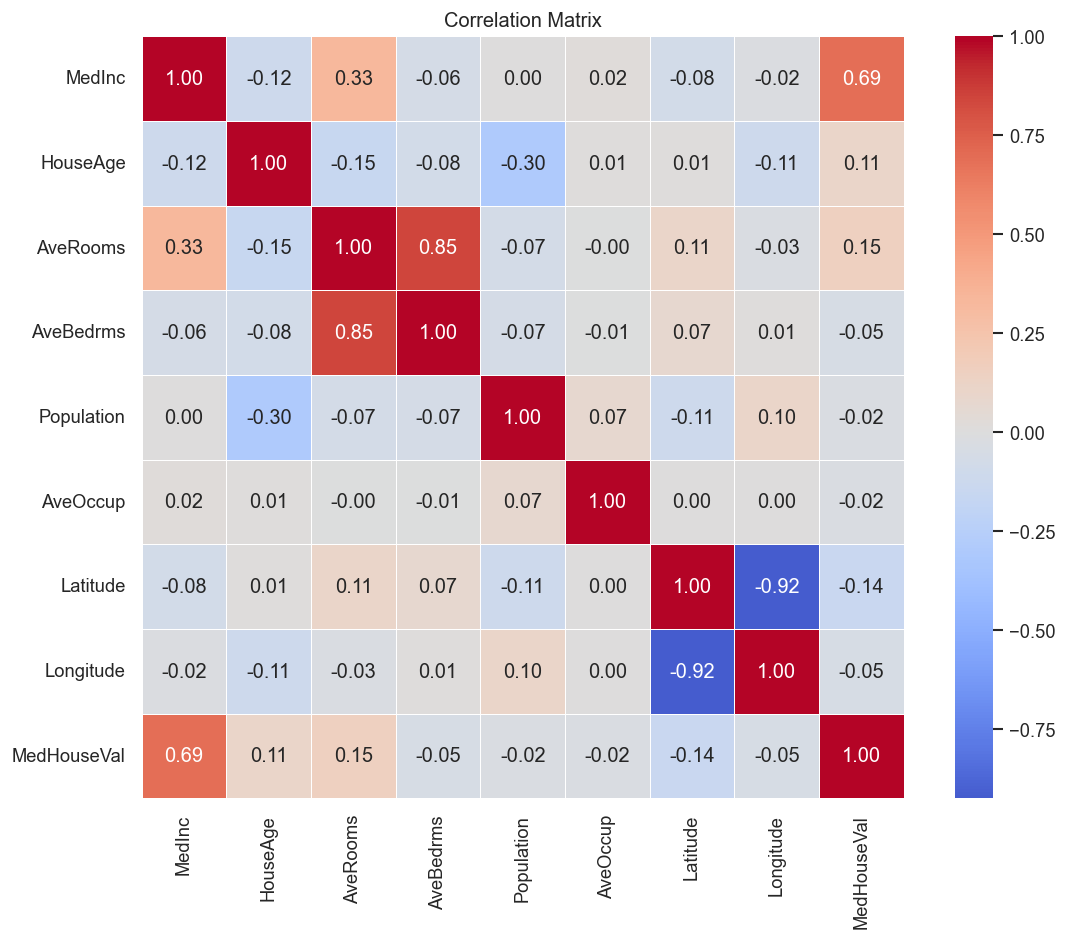

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


In [7]:
corr = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("figures/fig3_correlations.png", bbox_inches="tight")
plt.show()

# También útil ver solo la correlación con el target
print(corr["MedHouseVal"].sort_values(ascending=False))

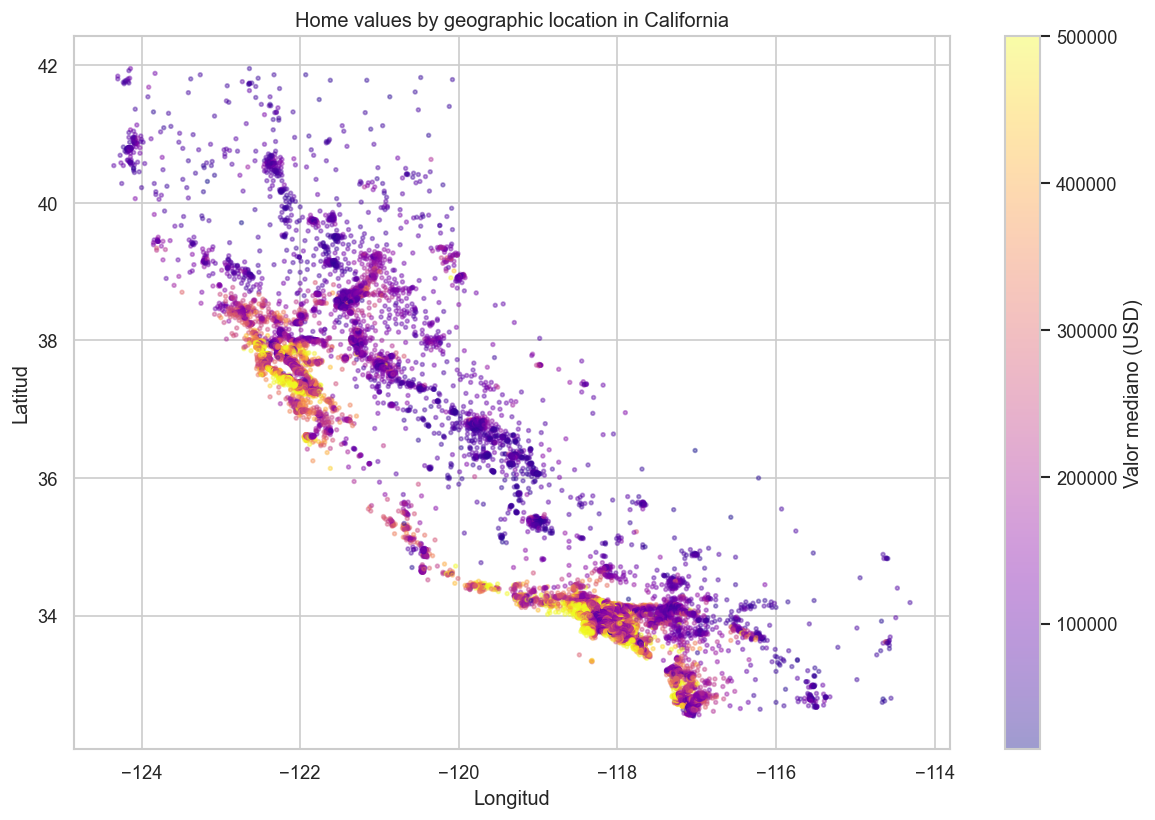

In [8]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    df["Longitude"], df["Latitude"],
    c=df["MedHouseVal"], cmap="plasma",
    alpha=0.4, s=5
)
plt.colorbar(scatter, label="Valor mediano (USD)")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Home values by geographic location in California")
plt.tight_layout()
plt.savefig("figures/fig4_map.png", bbox_inches="tight")
plt.show()

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]} registros")
print(f"Test:  {X_test.shape[0]} registros")
print(f"Proporción: {X_train.shape[0]/len(X):.0%} / {X_test.shape[0]/len(X):.0%}")

Train: 16512 registros
Test:  4128 registros
Proporción: 80% / 20%


In [12]:
# Entrenar baseline (predice siempre la media del train)
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

# Evaluar sobre el test
y_pred_baseline = baseline.predict(X_test)

mae_b  = mean_absolute_error(y_test, y_pred_baseline)
rmse_b = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_b   = r2_score(y_test, y_pred_baseline)

print("── Resultados del baseline ──────────────────")
print(f"MAE:  ${mae_b:,.0f}  ({mae_b/y_test.median()*100:.1f}% del valor mediano)")
print(f"RMSE: ${rmse_b:,.0f}")
print(f"R²:   {r2_b:.4f}")
baseline_value = baseline.constant_.item()
print(f"\nEl baseline siempre predice: ${baseline_value:,.0f}")

── Resultados del baseline ──────────────────
MAE:  $90,607  (50.7% del valor mediano)
RMSE: $114,486
R²:   -0.0002

El baseline siempre predice: $207,195


## Conclusiones

1. El dataset está limpio (0 nulos), lo que simplifica el pipeline.
2. `MedInc` es el predictor dominante (r ≈ 0.69).
3. `AveRooms`, `AveBedrms` y `AveOccup` tienen outliers que requieren tratamiento.
4. La componente geográfica es visualmente relevante.
5. El baseline (MAE = $XX,XXX) establece el piso para la Entrega 2.

**Para la Entrega 2 se compararán:**
- Regresión lineal / Ridge / Las so
- Random Forest
- XGBoost o LightGBM